## AQI Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8')

print("=" * 50)
print("   Delhi Air Quality Analysis — Initialized")
print(f"   Pandas  : {pd.__version__}")
print(f"   Numpy   : {np.__version__}")
print("=" * 50)

   Delhi Air Quality Analysis — Initialized
   Pandas  : 2.3.1
   Numpy   : 2.3.5


In [2]:
base_path = 'Data'
all_dfs = []

for station_folder in os.listdir(base_path):
    station_path = os.path.join(base_path, station_folder)
    if os.path.isdir(station_path):
        for file in os.listdir(station_path):
            if file.endswith('.csv'):
                file_path = os.path.join(station_path, file)
                df = pd.read_csv(file_path)
                df.columns = df.columns.str.strip().str.lower()
                df.columns = df.columns.str.replace(r'\s*\(.*?\)', '', regex=True).str.strip()
                df = df.loc[:, ~df.columns.duplicated(keep='first')]
                if 'timestamp' in df.columns:
                    df = df.rename(columns={'timestamp': 'datetime'})
                if 'datetime' in df.columns:
                    df['datetime'] = df['datetime'].astype(str).str.strip()
                    df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True, errors='coerce')
                df['station'] = station_folder
                all_dfs.append(df)

df_raw = pd.concat(all_dfs, ignore_index=True)
df_raw = df_raw.loc[:, ~df_raw.columns.duplicated(keep='first')]

print("=" * 50)
print(f"   Stations loaded : {df_raw['station'].nunique()}")
print(f"   Total records   : {len(df_raw):,}")
print(f"   Year distribution:")
print(df_raw['datetime'].dt.year.value_counts().sort_index().to_string())
print("=" * 50)

   Stations loaded : 8
   Total records   : 54,096
   Year distribution:
datetime
2019.00    6587
2020.00    6594
2021.00    6587
2022.00    6587
2023.00    4571
2024.00    4578


In [3]:
before = len(df_raw)
df_raw = df_raw.dropna(subset=['datetime'])
dropped = before - len(df_raw)

df_raw['year']      = df_raw['datetime'].dt.year
df_raw['month']     = df_raw['datetime'].dt.month
df_raw['day']       = df_raw['datetime'].dt.day
df_raw['dayofweek'] = df_raw['datetime'].dt.dayofweek

print(f"   Dropped : {dropped:,}")
print(f"   Remaining : {len(df_raw):,}")
print(df_raw['year'].value_counts().sort_index())

   Dropped : 18,592
   Remaining : 35,504
year
2019    6587
2020    6594
2021    6587
2022    6587
2023    4571
2024    4578
Name: count, dtype: int64


In [4]:
target_pollutants = ['pm2.5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'ozone']

available = [c for c in target_pollutants if c in df_raw.columns]
not_found = [c for c in target_pollutants if c not in df_raw.columns]

keep_cols = ['datetime', 'station', 'year', 'month', 'day', 'dayofweek'] + available
df = df_raw[keep_cols].copy()

for col in available:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("=" * 50)
print(f"   Available : {available}")
print(f"   Not found : {not_found}")
print(f"   Shape     : {df.shape}")

   Available : ['pm2.5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'ozone']
   Not found : []
   Shape     : (35504, 15)


In [5]:
df = df.sort_values(['station', 'datetime']).reset_index(drop=True)

for col in available:
    df[col] = df.groupby('station')[col].transform(lambda x: x.ffill(limit=3))

for col in available:
    df[col] = df.groupby(['station', 'year', 'month'])[col].transform(lambda x: x.fillna(x.median()))

print("=" * 50)
print("   Missing After Cleaning")
print("=" * 50)
print((df[available].isnull().sum() / len(df) * 100).round(2).to_string())
print(f"\n   Final shape : {df.shape}")

   Missing After Cleaning
pm2.5   3.01
pm10    3.01
no      2.75
no2     2.75
nox     2.75
nh3     2.75
so2     2.75
co      2.75
ozone   2.75

   Final shape : (35504, 15)


In [6]:
os.makedirs('data/clean', exist_ok=True)
df.to_csv('data/clean/delhi_aqi_clean.csv', index=False)

print("=" * 50)
print("   Phase 3 Complete — Clean Dataset Saved")
print("=" * 50)
print(f"   Path       : data/clean/delhi_aqi_clean.csv")
print(f"   Shape      : {df.shape}")
print(f"   Stations   : {df['station'].nunique()}")
print(f"   Date range : {df['datetime'].min()} → {df['datetime'].max()}")

   Phase 3 Complete — Clean Dataset Saved
   Path       : data/clean/delhi_aqi_clean.csv
   Shape      : (35504, 15)
   Stations   : 8
   Date range : 2019-01-01 00:00:00 → 2024-12-31 00:00:00


In [7]:
import subprocess
subprocess.run(['pip', 'install', 'openmeteo-requests', 'requests-cache', 'retry-requests'], 
               capture_output=True)

CompletedProcess(args=['pip', 'install', 'openmeteo-requests', 'requests-cache', 'retry-requests'], returncode=0, stdout=b'Defaulting to user installation because normal site-packages is not writeable\r\nRequirement already satisfied: openmeteo-requests in C:\\Users\\adith\\AppData\\Roaming\\Python\\Python313\\site-packages (1.7.5)\r\nRequirement already satisfied: requests-cache in C:\\Users\\adith\\AppData\\Roaming\\Python\\Python313\\site-packages (1.3.1)\r\nRequirement already satisfied: retry-requests in C:\\Users\\adith\\AppData\\Roaming\\Python\\Python313\\site-packages (2.0.0)\r\nRequirement already satisfied: niquests>=3.15.2 in C:\\Users\\adith\\AppData\\Roaming\\Python\\Python313\\site-packages (from openmeteo-requests) (3.17.0)\r\nRequirement already satisfied: openmeteo-sdk>=1.22.0 in C:\\Users\\adith\\AppData\\Roaming\\Python\\Python313\\site-packages (from openmeteo-requests) (1.25.0)\r\nRequirement already satisfied: attrs>=21.2 in C:\\Users\\adith\\AppData\\Roaming\\Py

In [8]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "start_date": "2019-01-01",
    "end_date": "2024-12-31",
    "daily": ["temperature_2m_mean", "relative_humidity_2m_mean",
              "wind_speed_10m_max", "precipitation_sum"],
    "timezone": "Asia/Kolkata"
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
daily = response.Daily()

weather_df = pd.DataFrame({
    "datetime": pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True).tz_localize(None),
        periods=daily.Variables(0).ValuesAsNumpy().shape[0],
        freq="D"
    ),
    "temperature":   daily.Variables(0).ValuesAsNumpy(),
    "humidity":      daily.Variables(1).ValuesAsNumpy(),
    "wind_speed":    daily.Variables(2).ValuesAsNumpy(),
    "precipitation": daily.Variables(3).ValuesAsNumpy()
})

print("=" * 50)
print(f"   Weather Shape      : {weather_df.shape}")
print(f"   Date range : {weather_df['datetime'].min()} → {weather_df['datetime'].max()}")

   Weather Shape      : (2192, 5)
   Date range : 2018-12-31 18:30:00 → 2024-12-30 18:30:00


In [9]:
df['datetime'] = pd.to_datetime(df['datetime']).dt.normalize()
weather_df['datetime'] = pd.to_datetime(weather_df['datetime']).dt.normalize()

df_merged = df.merge(weather_df, on='datetime', how='left')
df_merged.to_csv('data/clean/delhi_aqi_weather.csv', index=False)

print("=" * 50)
print("   Merge Complete")
print("=" * 50)
print(f"   Shape      : {df_merged.shape}")
print(f"   Columns    : {df_merged.columns.tolist()}")

   Merge Complete
   Shape      : (35504, 19)
   Columns    : ['datetime', 'station', 'year', 'month', 'day', 'dayofweek', 'pm2.5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'ozone', 'temperature', 'humidity', 'wind_speed', 'precipitation']


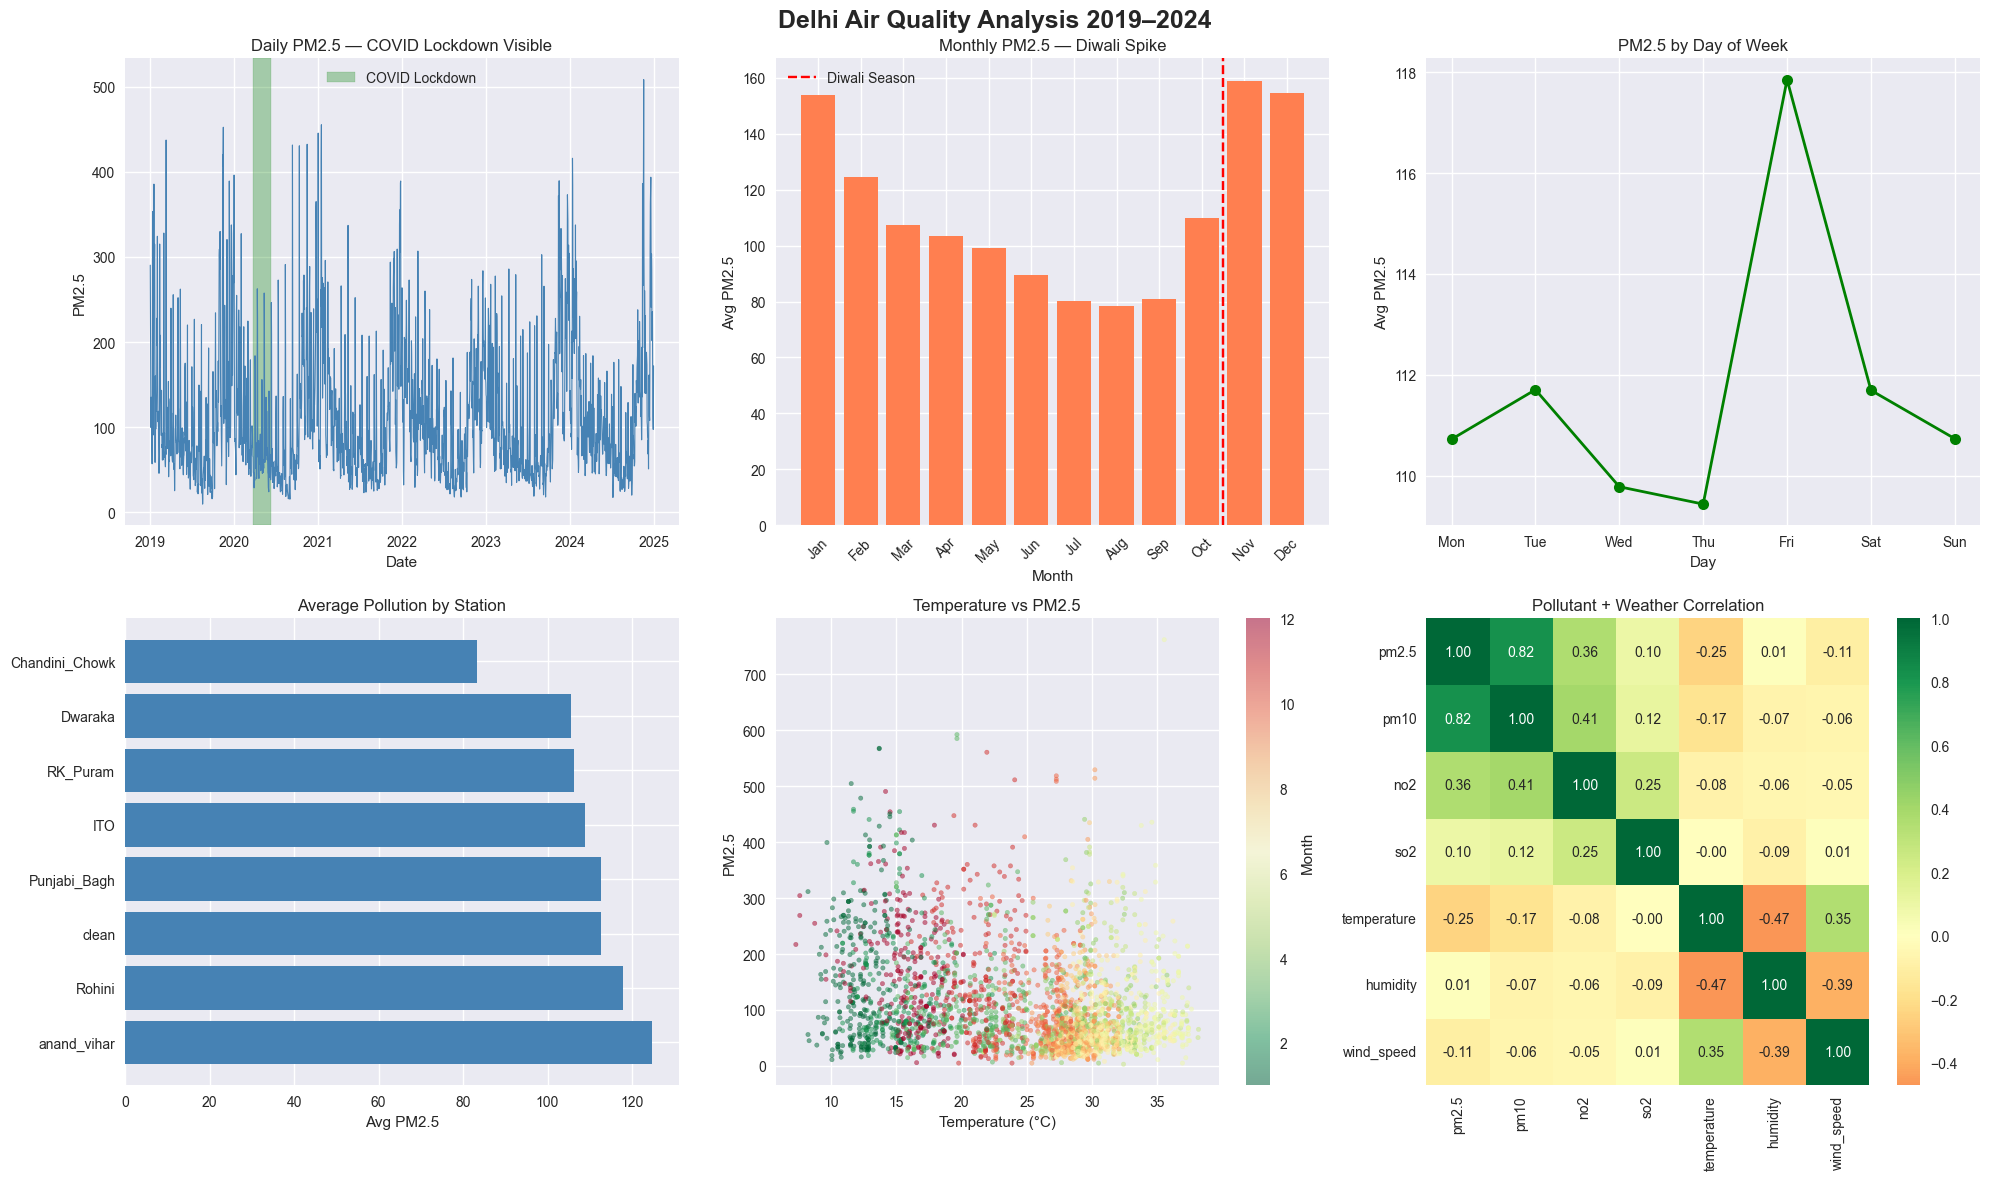

EDA saved → delhi_aqi_eda.png


In [10]:
df = pd.read_csv('data/clean/delhi_aqi_weather.csv', parse_dates=['datetime'])

pm_col = 'pm2.5' if 'pm2.5' in df.columns else 'pm10'
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Delhi Air Quality Analysis 2019–2024', fontsize=18, fontweight='bold')

daily_pm = df.groupby('datetime')[pm_col].mean()
axes[0,0].plot(daily_pm.index, daily_pm.values, linewidth=0.8, color='steelblue')
axes[0,0].axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-06-08'),
                  alpha=0.3, color='green', label='COVID Lockdown')
axes[0,0].set_title(f'Daily {pm_col.upper()} — COVID Lockdown Visible')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel(pm_col.upper())
axes[0,0].legend()

monthly_pm = df.groupby('month')[pm_col].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0,1].bar(months, monthly_pm.values, color='coral')
axes[0,1].axvline(x=9.5, color='red', linestyle='--', label='Diwali Season')
axes[0,1].set_title(f'Monthly {pm_col.upper()} — Diwali Spike')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel(f'Avg {pm_col.upper()}')
axes[0,1].legend()
plt.setp(axes[0,1].get_xticklabels(), rotation=45)

dow_pm = df.groupby('dayofweek')[pm_col].mean()
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[0,2].plot(days, dow_pm.values, 'g-o', markersize=8, linewidth=2)
axes[0,2].set_title(f'{pm_col.upper()} by Day of Week')
axes[0,2].set_xlabel('Day')
axes[0,2].set_ylabel(f'Avg {pm_col.upper()}')

station_pm = df.groupby('station')[pm_col].mean().sort_values(ascending=False)
axes[1,0].barh(station_pm.index, station_pm.values, color='steelblue')
axes[1,0].set_title('Average Pollution by Station')
axes[1,0].set_xlabel(f'Avg {pm_col.upper()}')

if 'temperature' in df.columns:
    sample = df.sample(min(3000, len(df)))
    sc = axes[1,1].scatter(sample['temperature'], sample[pm_col],
                           c=sample['month'], cmap='RdYlGn_r', alpha=0.5, s=10)
    plt.colorbar(sc, ax=axes[1,1], label='Month')
    axes[1,1].set_title(f'Temperature vs {pm_col.upper()}')
    axes[1,1].set_xlabel('Temperature (°C)')
    axes[1,1].set_ylabel(pm_col.upper())

corr_cols = [c for c in ['pm2.5','pm10','no2','so2','temperature','humidity','wind_speed'] if c in df.columns]
sns.heatmap(df[corr_cols].corr(), ax=axes[1,2], annot=True, fmt='.2f', cmap='RdYlGn', center=0)
axes[1,2].set_title('Pollutant + Weather Correlation')

plt.tight_layout()
plt.savefig('delhi_aqi_eda.png', dpi=300, bbox_inches='tight')
plt.show()
print("EDA saved → delhi_aqi_eda.png")

In [11]:
pm_col = 'pm2.5' if 'pm2.5' in df.columns else 'pm10'

daily = df.groupby(['station', 'year', 'month', 'day']).agg(
    pm=(pm_col, 'mean'),
    pm10=('pm10', 'mean'),
    no2=('no2', 'mean') if 'no2' in df.columns else ('pm10', 'mean'),
    temperature=('temperature', 'mean') if 'temperature' in df.columns else ('pm10', 'mean'),
    humidity=('humidity', 'mean') if 'humidity' in df.columns else ('pm10', 'mean'),
    wind_speed=('wind_speed', 'mean') if 'wind_speed' in df.columns else ('pm10', 'mean'),
    precipitation=('precipitation', 'sum') if 'precipitation' in df.columns else ('pm10', 'mean'),
).reset_index()

daily['date'] = pd.to_datetime(daily[['year', 'month', 'day']])
daily = daily.sort_values(['station', 'date']).reset_index(drop=True)

for lag in [1, 2, 3, 7]:
    daily[f'pm_lag_{lag}'] = daily.groupby('station')['pm'].shift(lag)

daily['pm_roll_3'] = daily.groupby('station')['pm'].transform(lambda x: x.rolling(3, min_periods=1).mean())
daily['pm_roll_7'] = daily.groupby('station')['pm'].transform(lambda x: x.rolling(7, min_periods=1).mean())

daily['is_diwali_season'] = daily['month'].isin([10, 11]).astype(int)
daily['is_winter'] = daily['month'].isin([11, 12, 1, 2]).astype(int)

daily = daily.dropna()

print("=" * 50)
print(f"   Feature Engineering Complete")
print(f"   Shape : {daily.shape}")
print("=" * 50)

   Feature Engineering Complete
   Shape : (14959, 20)


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb

le = LabelEncoder()
daily['station_enc'] = le.fit_transform(daily['station'])

feature_cols = ['pm10', 'no2', 'temperature', 'humidity', 'wind_speed', 'precipitation',
                'pm_lag_1', 'pm_lag_2', 'pm_lag_3', 'pm_lag_7',
                'pm_roll_3', 'pm_roll_7', 'month', 'day',
                'is_diwali_season', 'is_winter', 'station_enc']
feature_cols = [f for f in feature_cols if f in daily.columns]

X = daily[feature_cols]
y = daily['pm']

train_mask = daily['year'] <= 2022
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                          max_depth=6, subsample=0.8,
                          random_state=42, verbosity=0)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred = model.predict(X_test)
print("=" * 50)
print(f"   R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"   MAE      : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"   Train    : {len(X_train):,} | Test : {len(X_test):,}")
print("=" * 50)

[0]	validation_0-rmse:85.70285
[50]	validation_0-rmse:18.12554
[100]	validation_0-rmse:14.12631
[150]	validation_0-rmse:13.12542
[200]	validation_0-rmse:12.39983
[250]	validation_0-rmse:11.90098
[299]	validation_0-rmse:11.59724
   R² Score : 0.9833
   MAE      : 6.39
   Train    : 9,888 | Test : 5,071


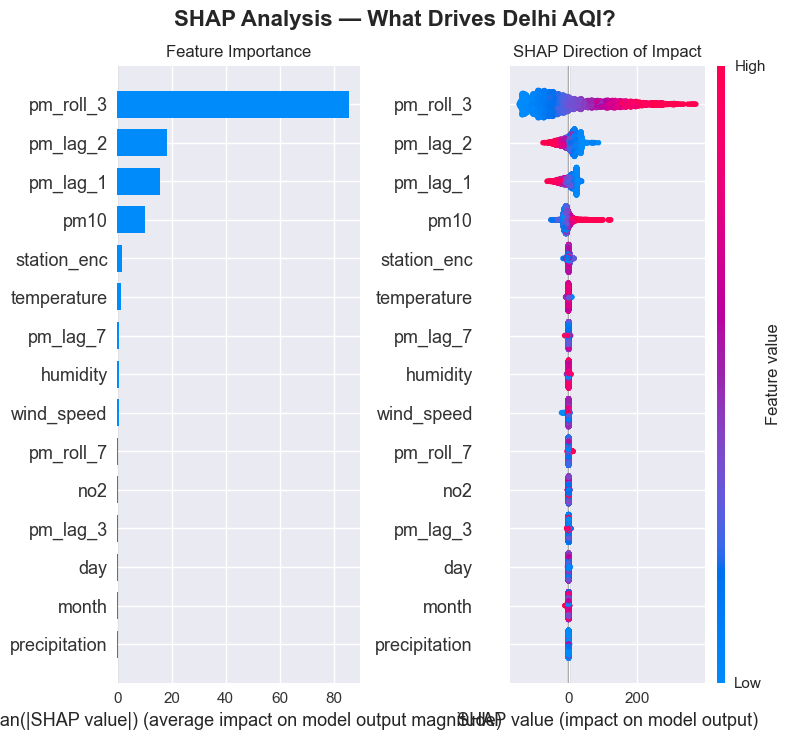

   Top 5 AQI Drivers
    feature  importance
  pm_roll_3       85.36
   pm_lag_2       18.51
   pm_lag_1       15.69
       pm10       10.19
station_enc        1.84

   SHAP plot saved → delhi_aqi_shap.png


In [13]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('SHAP Analysis — What Drives Delhi AQI?', fontsize=16, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
axes[0].set_title('Feature Importance')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
axes[1].set_title('SHAP Direction of Impact')

plt.tight_layout()
plt.savefig('delhi_aqi_shap.png', dpi=300, bbox_inches='tight')
plt.show()

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': np.abs(shap_values).mean(0)
}).sort_values('importance', ascending=False)

print("=" * 50)
print("   Top 5 AQI Drivers")
print("=" * 50)
print(importance_df.head().to_string(index=False))
print("\n   SHAP plot saved → delhi_aqi_shap.png")